<a href="https://colab.research.google.com/github/nethra0906/NethraKrishnan/blob/main/EDA_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install & load packages**

In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"

**Upload & Load Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

df_raw = pd.read_csv("recid.csv")

print(f"\nShape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\nColumns:\n{list(df_raw.columns)}")
print(f"\nFirst 3 rows:\n{df_raw.head(3).to_string()}")
print(f"\nData types:\n{df_raw.dtypes.to_string()}")

Saving recid.csv to recid.csv

Shape: 1445 rows × 19 columns

Columns:
['rownames', 'black', 'alcohol', 'drugs', 'super', 'married', 'felon', 'workprg', 'property', 'person', 'priors', 'educ', 'rules', 'age', 'tserved', 'follow', 'durat', 'cens', 'ldurat']

First 3 rows:
   rownames  black  alcohol  drugs  super  married  felon  workprg  property  person  priors  educ  rules  age  tserved  follow  durat  cens    ldurat
0         1      0        1      0      1        1      0        1         0       0       0     7      2  441       30      72     72     1  4.276666
1         2      1        0      0      1        0      1        1         1       0       0    12      0  307       19      75     75     1  4.317488
2         3      0        0      0      0        0      0        1         1       0       0     9      5  262       27      81      9     0  2.197225

Data types:
rownames      int64
black         int64
alcohol       int64
drugs         int64
super         int64
married    

**Basic Statistical Analysis**

In [3]:
print("BASIC STATISTICAL ANALYSIS")

df = df_raw.drop(columns=["rownames"]).copy()

binary_cols = [
    "black", "alcohol", "drugs", "super", "married",
    "felon", "workprg", "property", "person", "cens"
]
count_cols = ["priors", "educ", "rules"]
cont_cols = ["age", "tserved", "follow", "durat", "ldurat"]

print("\nDescriptive statistics (continuous)")
print(df[cont_cols].describe().round(2).to_string())

print("\nDescriptive statistics (counts / ordinal)")
print(df[count_cols].describe().round(2).to_string())

print("\nBinary feature prevalence (%)")
for col in binary_cols:
    print(f"  {col:<12}: {df[col].mean() * 100:.1f}%")

print("\nSkewness & Kurtosis (continuous features)")
stats_summary = pd.DataFrame({
    "skewness": df[cont_cols].skew().round(3),
    "kurtosis": df[cont_cols].kurt().round(3)
})

print(stats_summary.to_string())

BASIC STATISTICAL ANALYSIS

Descriptive statistics (continuous)
           age  tserved   follow    durat   ldurat
count  1445.00  1445.00  1445.00  1445.00  1445.00
mean    345.44    19.18    74.89    55.37     3.75
std     121.05    20.96     3.50    27.30     0.93
min     198.00     0.00    70.00     1.00     0.00
25%     258.00     6.00    72.00    27.00     3.30
50%     307.00    12.00    74.00    71.00     4.26
75%     395.00    25.00    78.00    76.00     4.33
max     933.00   219.00    81.00    81.00     4.39

Descriptive statistics (counts / ordinal)
        priors     educ    rules
count  1445.00  1445.00  1445.00
mean      1.43     9.70     1.19
std       2.85     2.44     2.30
min       0.00     1.00     0.00
25%       0.00     8.00     0.00
50%       0.00    10.00     0.00
75%       2.00    11.00     1.00
max      28.00    19.00    27.00

Binary feature prevalence (%)
  black       : 48.5%
  alcohol     : 21.0%
  drugs       : 24.2%
  super       : 69.4%
  married     : 25

**Handle Missing Data**

In [4]:
print("HANDLING MISSING DATA")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

if missing.sum() == 0:
    print("\nNo missing values detected in any column.")
    print("Strategy: No imputation required - dataset is complete.")
else:
    print(report[report["missing_count"] > 0].to_string())

HANDLING MISSING DATA

No missing values detected in any column.
Strategy: No imputation required - dataset is complete.


**Data Cleaning**

In [5]:
print("DATA CLEANING")

dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

if dupes > 0:
    df = df.drop_duplicates()
    print(f"Removed {dupes} duplicate(s). New shape: {df.shape}")
else:
    print("No duplicates found.")

bad_durat = df[(df["durat"] < 1) | (df["durat"] > df["follow"])]
print(f"\ndurat < 1 or durat > follow: {len(bad_durat)} rows")

print()
valid_binary = True

for col in binary_cols:
    invalid = df[~df[col].isin([0, 1])]
    if len(invalid) > 0:
        print(f"Non-binary values in '{col}': {len(invalid)}")
        valid_binary = False

if valid_binary:
    print("All binary columns contain only 0 / 1.")

print("\nIQR-based outlier counts (continuous)")

for col in cont_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col:<12}: {outliers:>4} outliers (fence [{lower:.1f}, {upper:.1f}])")

DATA CLEANING

Duplicate rows: 0
No duplicates found.

durat < 1 or durat > follow: 0 rows

All binary columns contain only 0 / 1.

IQR-based outlier counts (continuous)
age         :   78 outliers (fence [52.5, 600.5])
tserved     :   74 outliers (fence [-22.5, 53.5])
follow      :    0 outliers (fence [63.0, 87.0])
durat       :    0 outliers (fence [-46.5, 149.5])
ldurat      :   66 outliers (fence [1.7, 5.9])


**Data Transformation**

In [6]:
print("DATA TRANSFORMATION")

df["age_years"] = (df["age"] / 12).round(2)
df["tserved_years"] = (df["tserved"] / 12).round(2)

print("age_years = age / 12")
print("tserved_years = tserved / 12")

df["rearrested"] = (df["cens"] == 0).astype(int)
print("rearrested = 1 if re-arrested (cens == 0)")


def educ_tier(grade):
    if grade <= 6:
        return "≤6th grade"
    elif grade <= 8:
        return "7th–8th"
    elif grade <= 11:
        return "9th–11th"
    elif grade == 12:
        return "High School"
    elif grade <= 15:
        return "Some College"
    return "College+"


educ_order = [
    "≤6th grade", "7th–8th", "9th–11th",
    "High School", "Some College", "College+"
]

df["educ_label"] = df["educ"].apply(educ_tier)
print("educ_label = education tier from grade level")

df["priors_bin"] = pd.cut(
    df["priors"],
    bins=[-1, 0, 2, 5, df["priors"].max()],
    labels=["0", "1–2", "3–5", "6+"]
)
print("priors_bin = priors grouped into 4 bands")

for col in ["age_years", "tserved_years", "priors", "rules"]:
    df[f"{col}_z"] = stats.zscore(df[col]).round(4)

print("*_z = z-score standardised versions")

print(f"\nFinal shape: {df.shape}")

new_cols = [col for col in df.columns if col not in df_raw.columns]
print(f"New columns: {new_cols}")

DATA TRANSFORMATION
age_years = age / 12
tserved_years = tserved / 12
rearrested = 1 if re-arrested (cens == 0)
educ_label = education tier from grade level
priors_bin = priors grouped into 4 bands
*_z = z-score standardised versions

Final shape: (1445, 27)
New columns: ['age_years', 'tserved_years', 'rearrested', 'educ_label', 'priors_bin', 'age_years_z', 'tserved_years_z', 'priors_z', 'rules_z']


**Univariate · Survival Time Distribution**

UNIVARIATE ANALYSIS


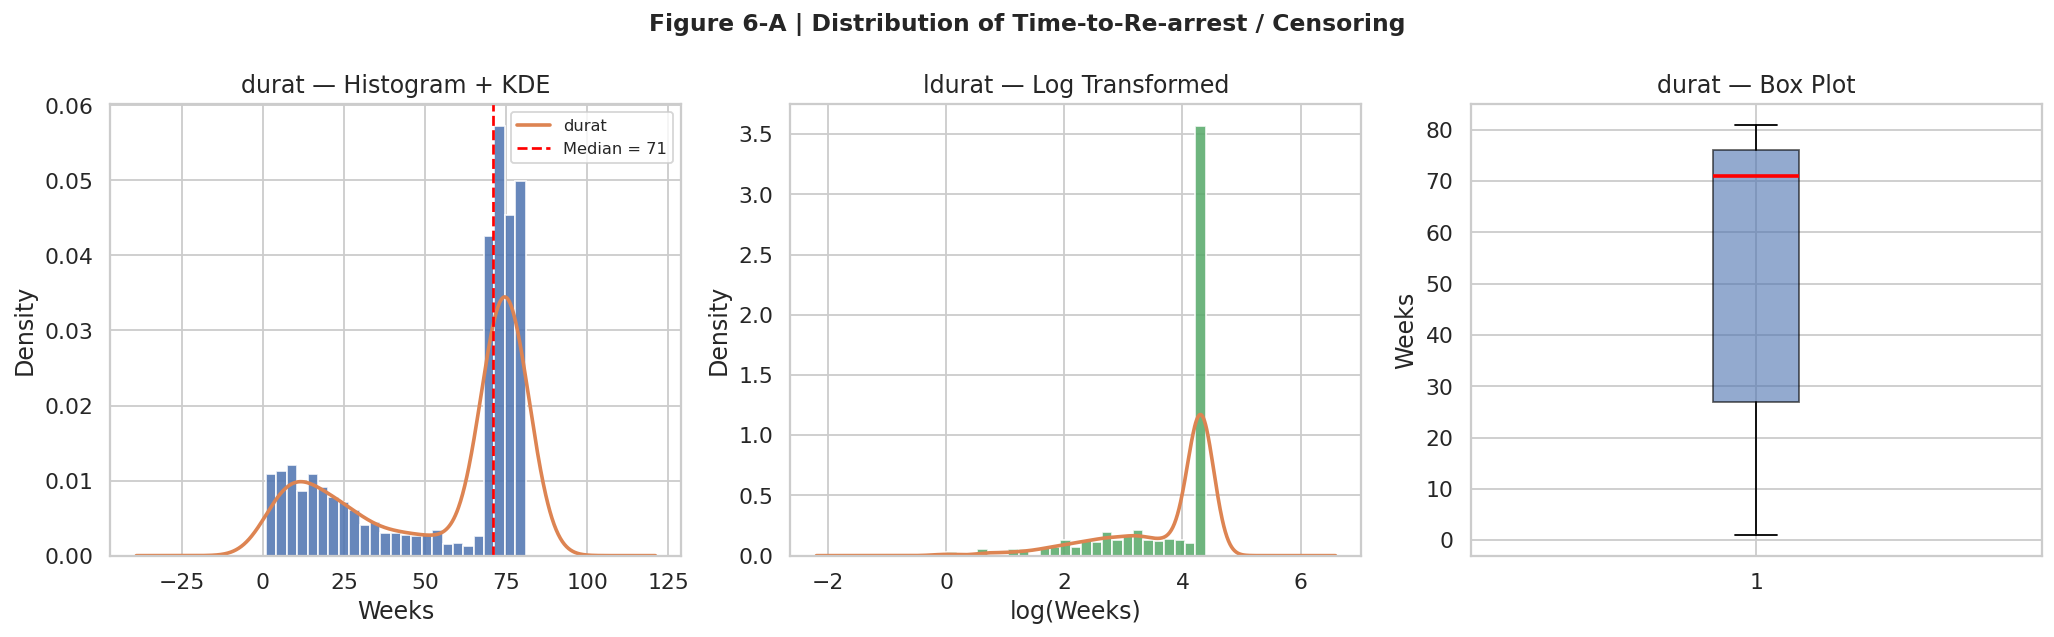

In [7]:
print("UNIVARIATE ANALYSIS")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Figure 6-A | Distribution of Time-to-Re-arrest / Censoring",
    fontsize=13,
    fontweight="bold"
)

# Histogram + KDE for durat
axes[0].hist(
    df["durat"],
    bins=25,
    density=True,
    color="#4C72B0",
    edgecolor="white",
    alpha=0.85
)
df["durat"].plot.kde(ax=axes[0], color="#DD8452", linewidth=2)

median = df["durat"].median()
axes[0].axvline(
    median,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {median:.0f}"
)
axes[0].set(
    title="durat — Histogram + KDE",
    xlabel="Weeks",
    ylabel="Density"
)
axes[0].legend(fontsize=9)

# Histogram + KDE for log-transformed duration
axes[1].hist(
    df["ldurat"],
    bins=25,
    density=True,
    color="#55A868",
    edgecolor="white",
    alpha=0.85
)
df["ldurat"].plot.kde(ax=axes[1], color="#DD8452", linewidth=2)
axes[1].set(
    title="ldurat — Log Transformed",
    xlabel="log(Weeks)",
    ylabel="Density"
)

# Box plot
axes[2].boxplot(
    df["durat"],
    patch_artist=True,
    boxprops={"facecolor": "#4C72B0", "alpha": 0.6},
    medianprops={"color": "red", "linewidth": 2},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4}
)
axes[2].set(title="durat — Box Plot", ylabel="Weeks")

plt.tight_layout()
plt.show()

**Univariate · Binary Feature Prevalences**

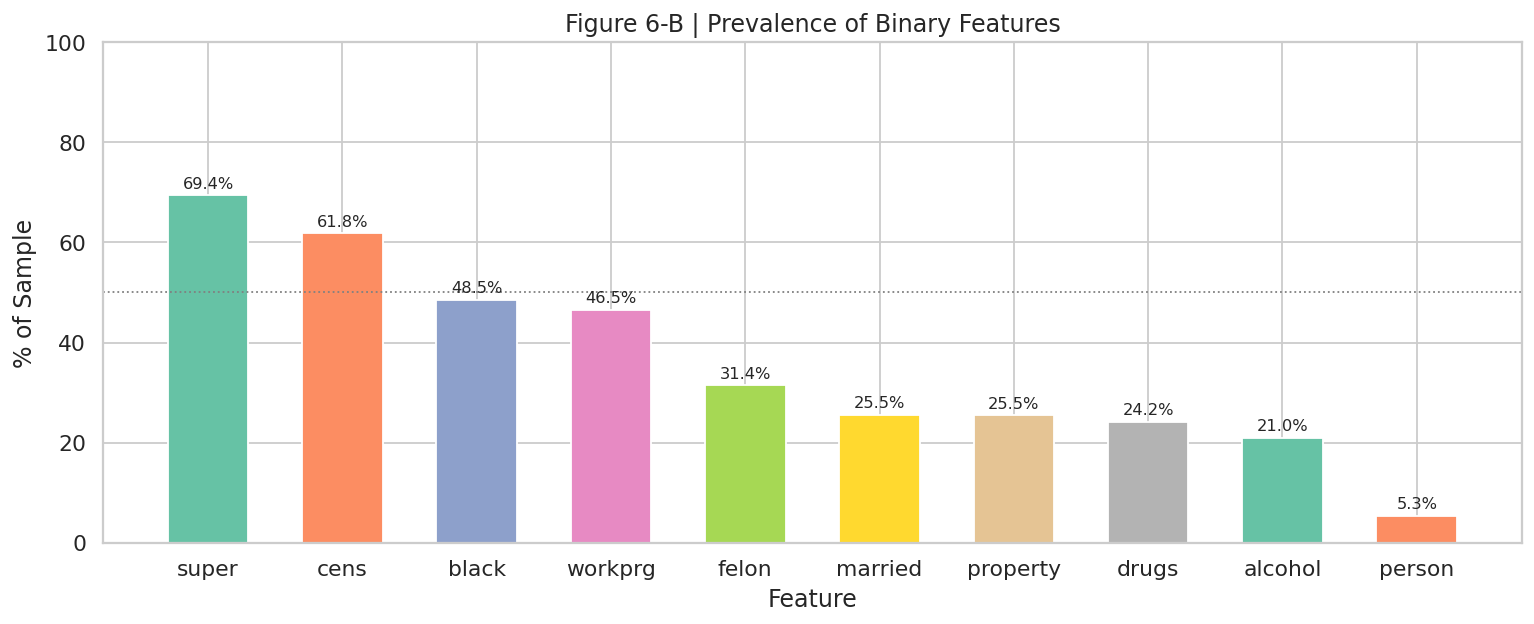

In [8]:
prev = df[binary_cols].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    prev.index,
    prev.values,
    color=sns.color_palette("Set2", len(prev)),
    edgecolor="white",
    width=0.6
)

for bar, value in zip(bars, prev.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.axhline(50, color="grey", linestyle=":", linewidth=1)

ax.set(
    title="Figure 6-B | Prevalence of Binary Features",
    xlabel="Feature",
    ylabel="% of Sample",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

**Univariate · Continuous Feature KDE Grid**

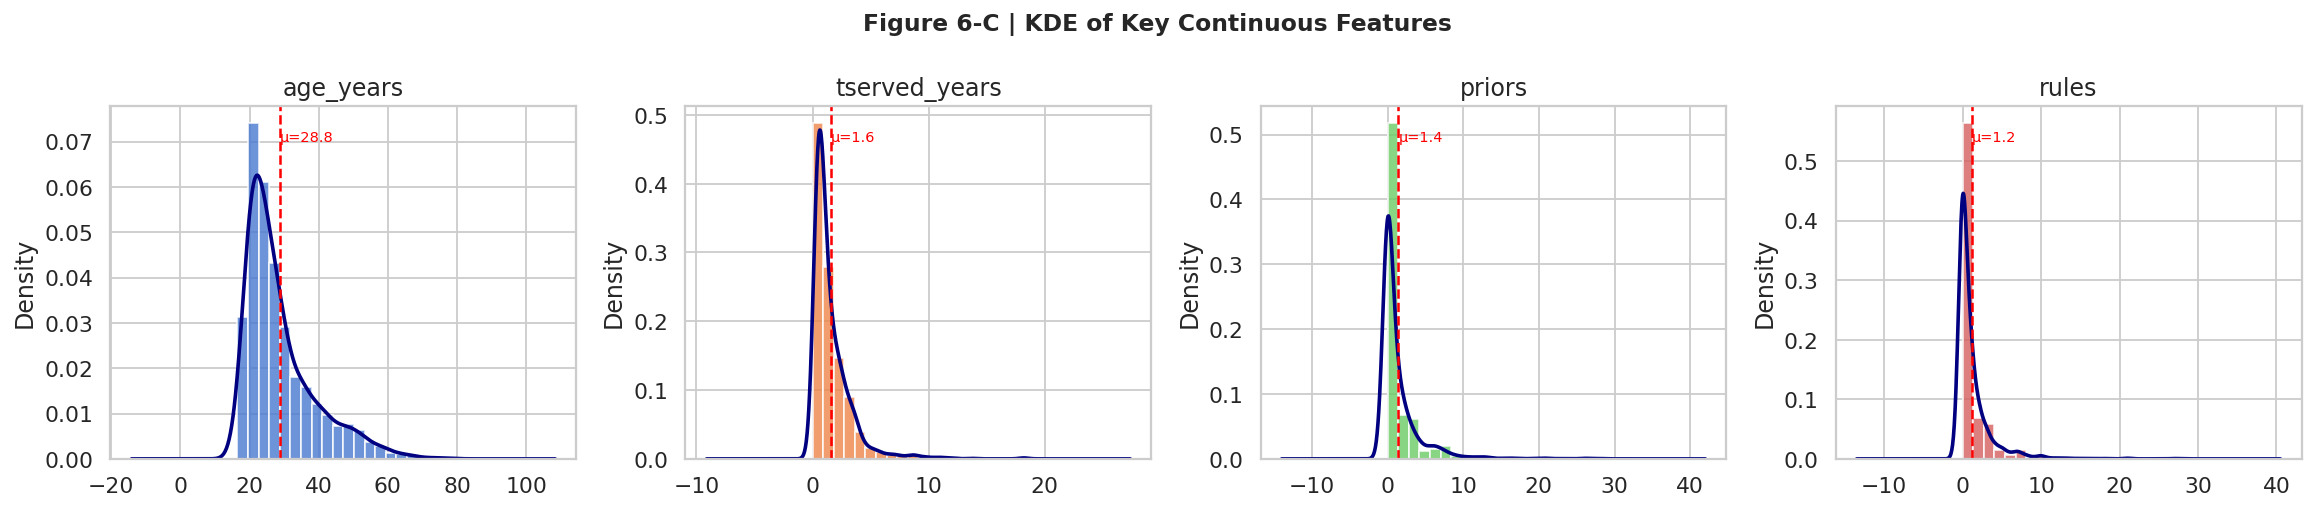

In [9]:
cont_show = ["age_years", "tserved_years", "priors", "rules"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    "Figure 6-C | KDE of Key Continuous Features",
    fontsize=13,
    fontweight="bold"
)

for ax, col, color in zip(axes, cont_show, sns.color_palette("muted", 4)):
    ax.hist(
        df[col],
        bins=20,
        density=True,
        color=color,
        edgecolor="white",
        alpha=0.8
    )

    df[col].plot.kde(ax=ax, color="navy", linewidth=2)

    mean = df[col].mean()
    ax.axvline(mean, color="red", linestyle="--", linewidth=1.4)
    ax.annotate(
        f"μ={mean:.1f}",
        xy=(mean, ax.get_ylim()[1] * 0.9),
        color="red",
        fontsize=8,
        ha="left"
    )

    ax.set(title=col, xlabel="", ylabel="Density")

plt.tight_layout()
plt.show()

**Univariate · Education Distribution**

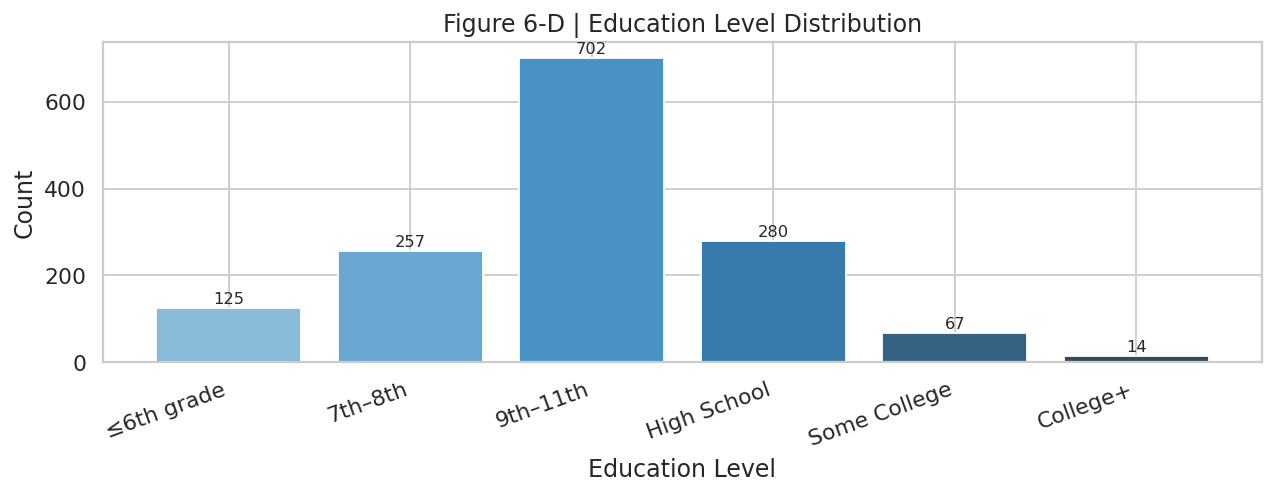

In [10]:
educ_counts = (
    df["educ_label"]
    .value_counts()
    .reindex(educ_order)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    educ_counts.index,
    educ_counts.values,
    color=sns.color_palette("Blues_d", len(educ_counts)),
    edgecolor="white"
)

for bar, value in zip(bars, educ_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(value),
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set(
    title="Figure 6-D | Education Level Distribution",
    xlabel="Education Level",
    ylabel="Count"
)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Bivariate · Survival Time by Re-arrest Status**

BIVARIATE ANALYSIS


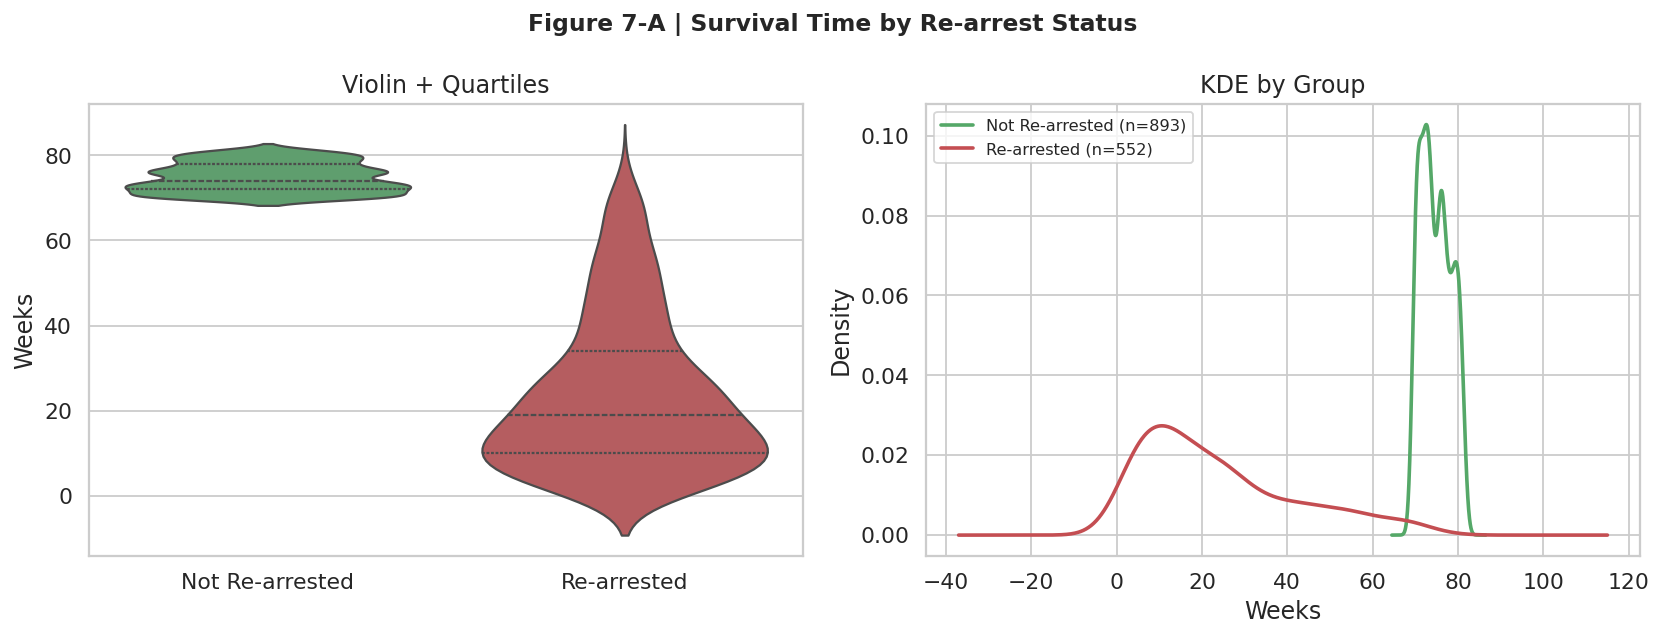

In [11]:
print("BIVARIATE ANALYSIS")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Figure 7-A | Survival Time by Re-arrest Status",
    fontsize=13,
    fontweight="bold"
)

df["rearrested_label"] = df["rearrested"].map({
    0: "Not Re-arrested",
    1: "Re-arrested"
})

sns.violinplot(
    data=df,
    x="rearrested_label",
    y="durat",
    ax=axes[0],
    palette=["#55A868", "#C44E52"],
    inner="quartile"
)

axes[0].set(
    title="Violin + Quartiles",
    xlabel="",
    ylabel="Weeks"
)

labels = ["Not Re-arrested", "Re-arrested"]
colors = ["#55A868", "#C44E52"]

for value, label, color in zip([0, 1], labels, colors):
    subset = df[df["rearrested"] == value]["durat"]
    subset.plot.kde(
        ax=axes[1],
        label=f"{label} (n={len(subset)})",
        color=color,
        linewidth=2
    )

axes[1].set(
    title="KDE by Group",
    xlabel="Weeks",
    ylabel="Density"
)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Bivariate · Re-arrest Rate by Risk Factor**

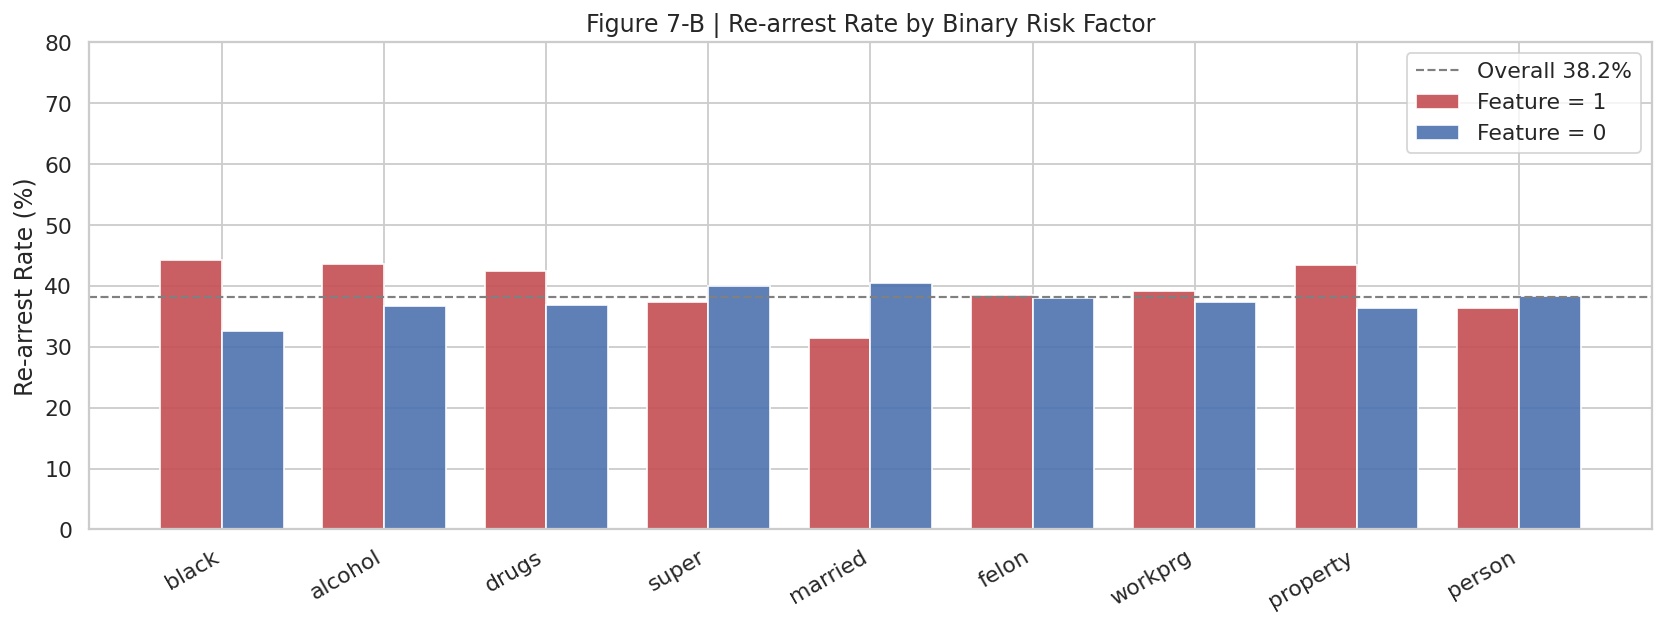

In [12]:
risk_cols = [
    "black", "alcohol", "drugs", "super", "married",
    "felon", "workprg", "property", "person"
]

rr_yes = []
rr_no = []

for col in risk_cols:
    rr_yes.append(df[df[col] == 1]["rearrested"].mean() * 100)
    rr_no.append(df[df[col] == 0]["rearrested"].mean() * 100)

x = np.arange(len(risk_cols))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(
    x - width / 2, rr_yes, width,
    label="Feature = 1",
    color="#C44E52",
    edgecolor="white",
    alpha=0.9
)

ax.bar(
    x + width / 2, rr_no, width,
    label="Feature = 0",
    color="#4C72B0",
    edgecolor="white",
    alpha=0.9
)

overall = df["rearrested"].mean() * 100

ax.axhline(
    overall,
    color="grey",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall {overall:.1f}%"
)

ax.set_xticks(x)
ax.set_xticklabels(risk_cols, rotation=30, ha="right")

ax.set(
    title="Figure 7-B | Re-arrest Rate by Binary Risk Factor",
    ylabel="Re-arrest Rate (%)",
    ylim=(0, 80)
)

ax.legend()
plt.tight_layout()
plt.show()

**Bivariate · Scatter + OLS Regression**

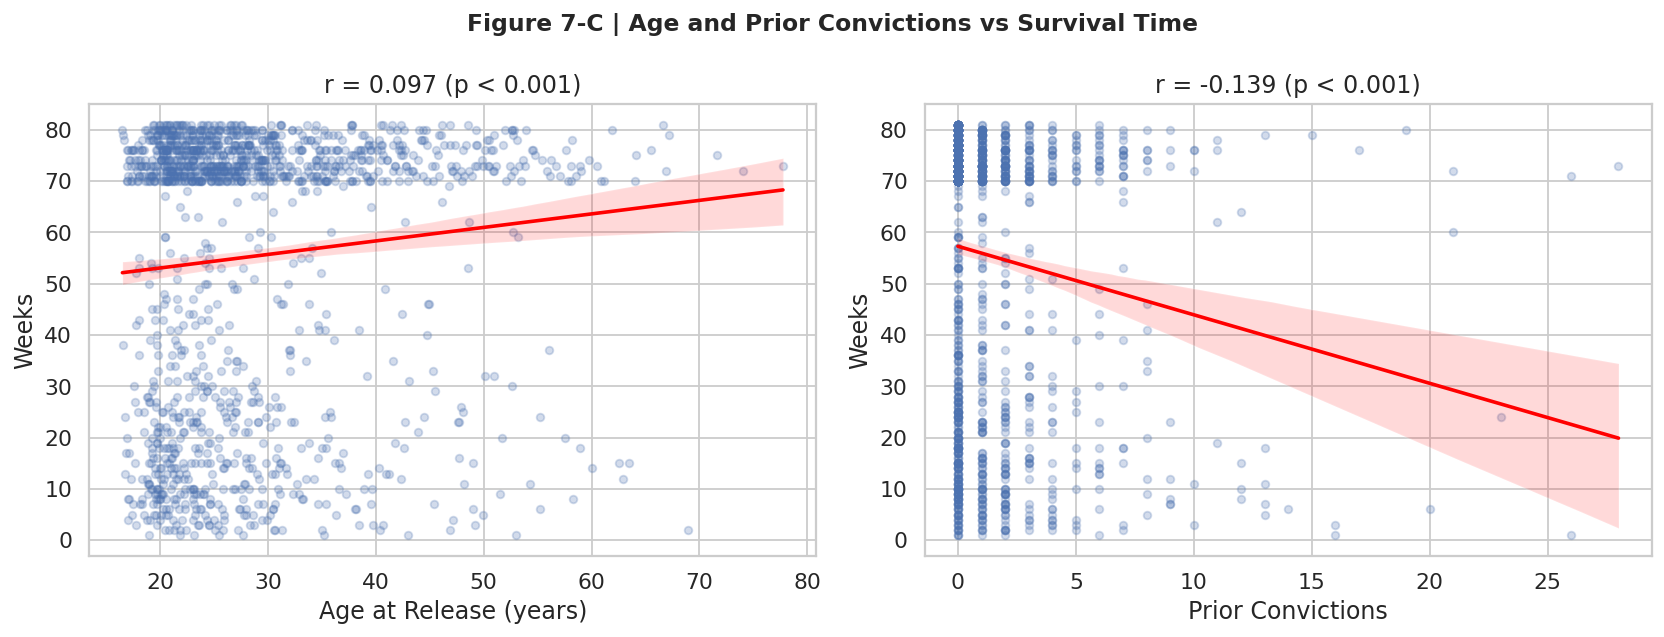

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Figure 7-C | Age and Prior Convictions vs Survival Time",
    fontsize=13,
    fontweight="bold"
)

columns = ["age_years", "priors"]
labels = ["Age at Release (years)", "Prior Convictions"]

for ax, col, label in zip(axes, columns, labels):
    r, p = stats.pearsonr(df[col], df["durat"])
    p_value = "< 0.001" if p < 0.001 else f"= {p:.3f}"

    sns.regplot(
        data=df,
        x=col,
        y="durat",
        ax=ax,
        scatter_kws={
            "alpha": 0.25,
            "s": 18,
            "color": "#4C72B0"
        },
        line_kws={
            "color": "red",
            "linewidth": 2
        }
    )

    ax.set(
        title=f"r = {r:.3f} (p {p_value})",
        xlabel=label,
        ylabel="Weeks"
    )

plt.tight_layout()
plt.show()

**Bivariate · Survival Time by Education Level**

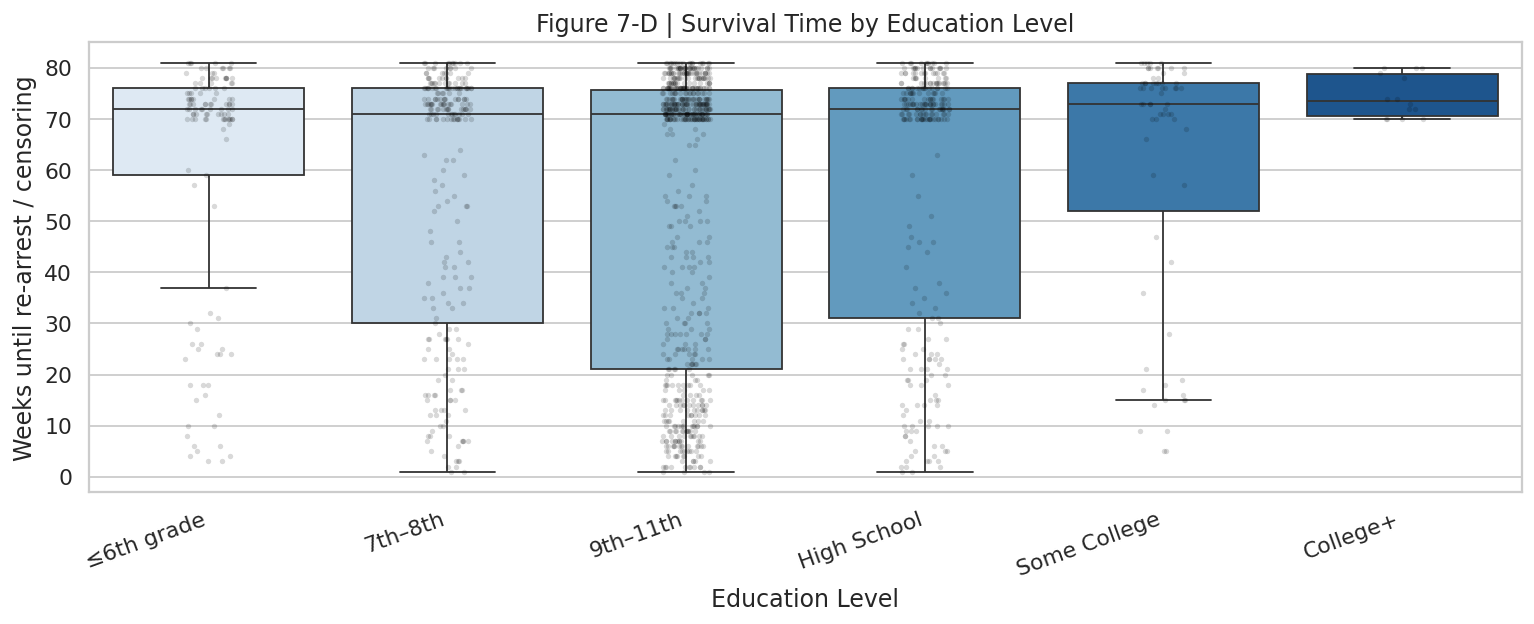

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

df["educ_label_ord"] = pd.Categorical(
    df["educ_label"],
    categories=educ_order,
    ordered=True
)

sns.boxplot(
    data=df,
    x="educ_label_ord",
    y="durat",
    ax=ax,
    palette="Blues",
    showfliers=False
)

sns.stripplot(
    data=df,
    x="educ_label_ord",
    y="durat",
    ax=ax,
    color="black",
    alpha=0.15,
    size=3,
    jitter=True
)

ax.set(
    title="Figure 7-D | Survival Time by Education Level",
    xlabel="Education Level",
    ylabel="Weeks until re-arrest / censoring"
)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Multivariate · Correlation Heatmap**

MULTIVARIATE ANALYSIS


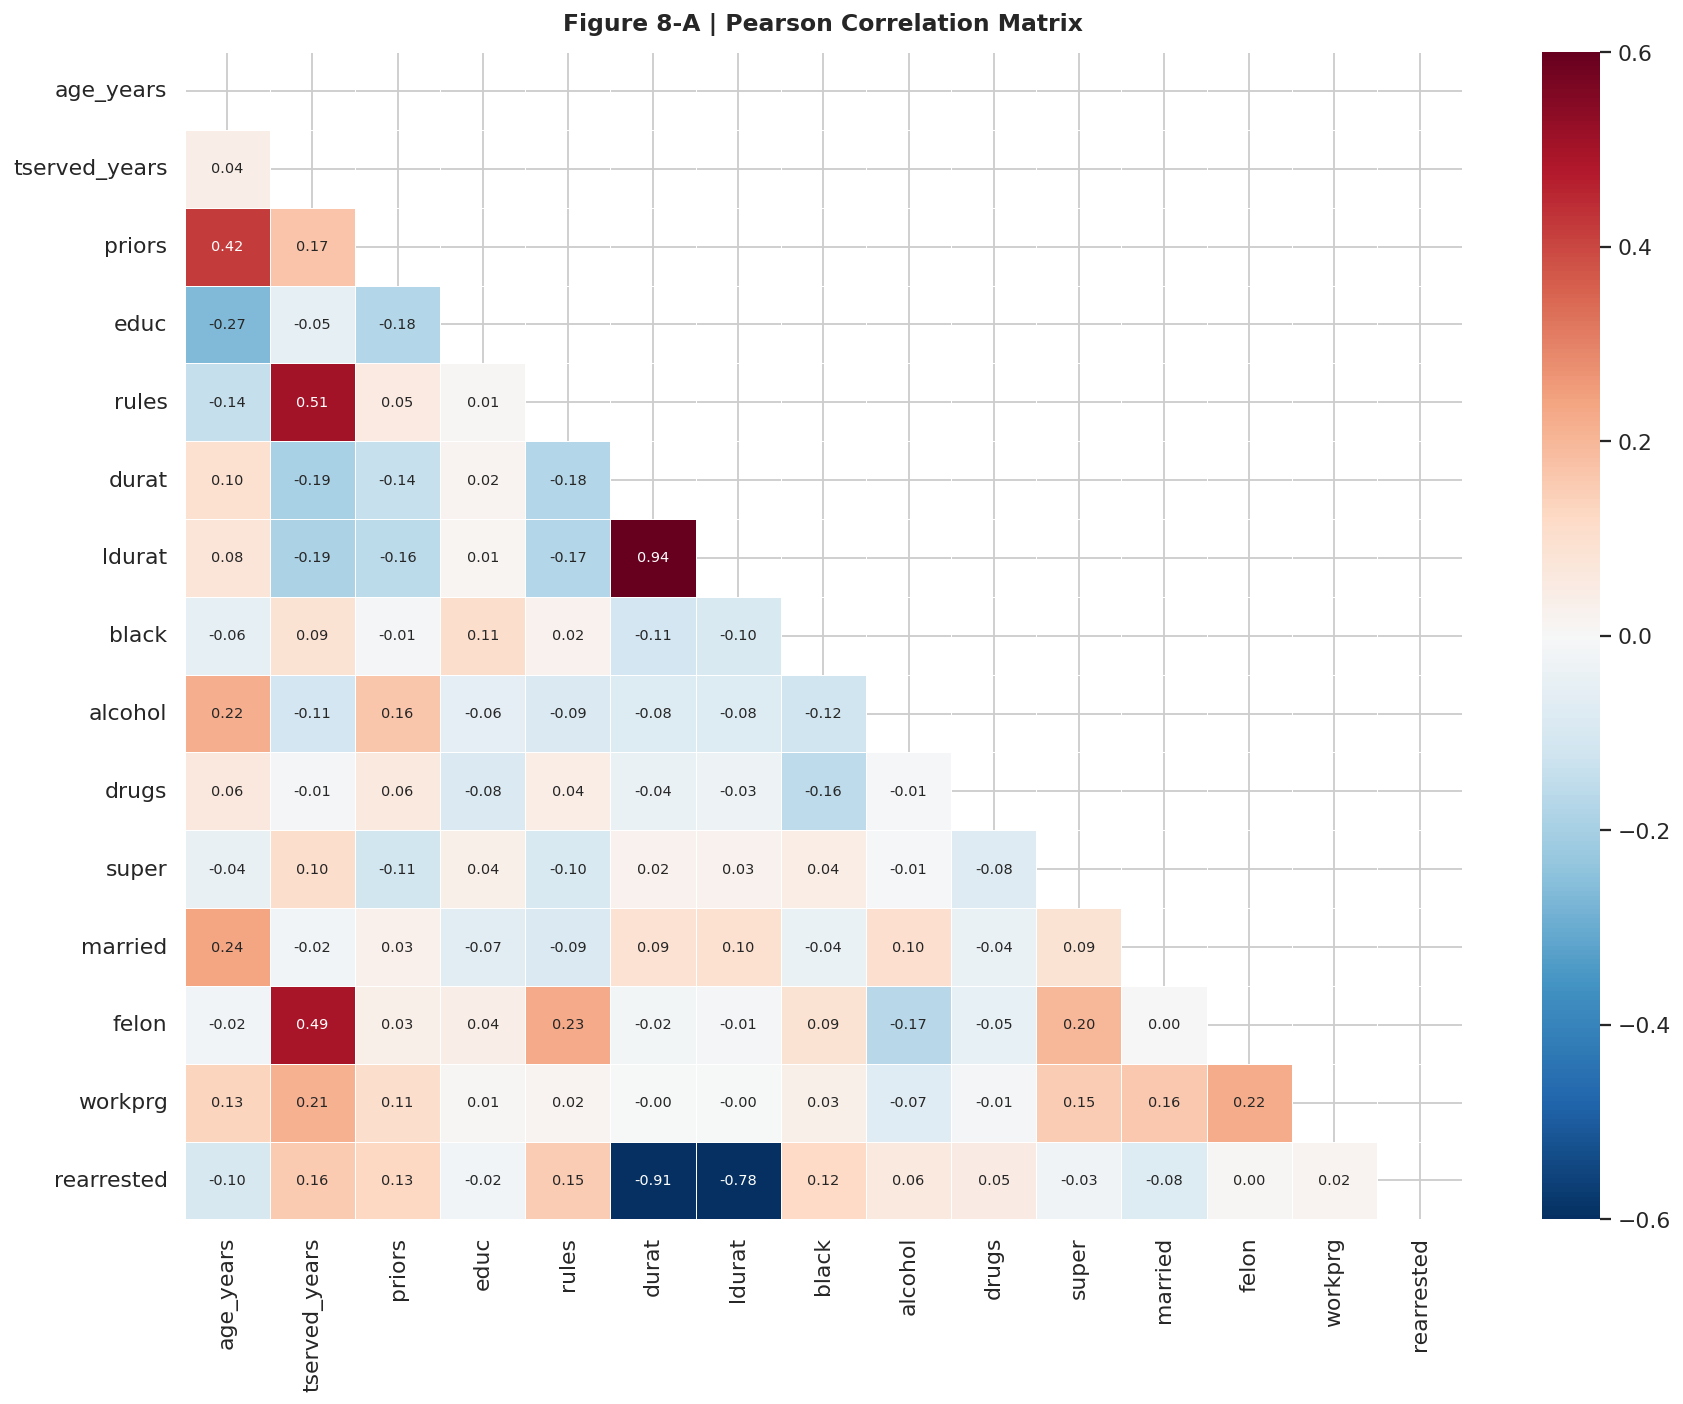

In [15]:
print("MULTIVARIATE ANALYSIS")

num_cols = [
    "age_years", "tserved_years", "priors", "educ", "rules",
    "durat", "ldurat", "black", "alcohol", "drugs", "super",
    "married", "felon", "workprg", "rearrested"
]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=0.5,
    annot_kws={"size": 8},
    ax=ax
)

ax.set_title(
    "Figure 8-A | Pearson Correlation Matrix",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
plt.show()

**Multivariate · Pair Plot**

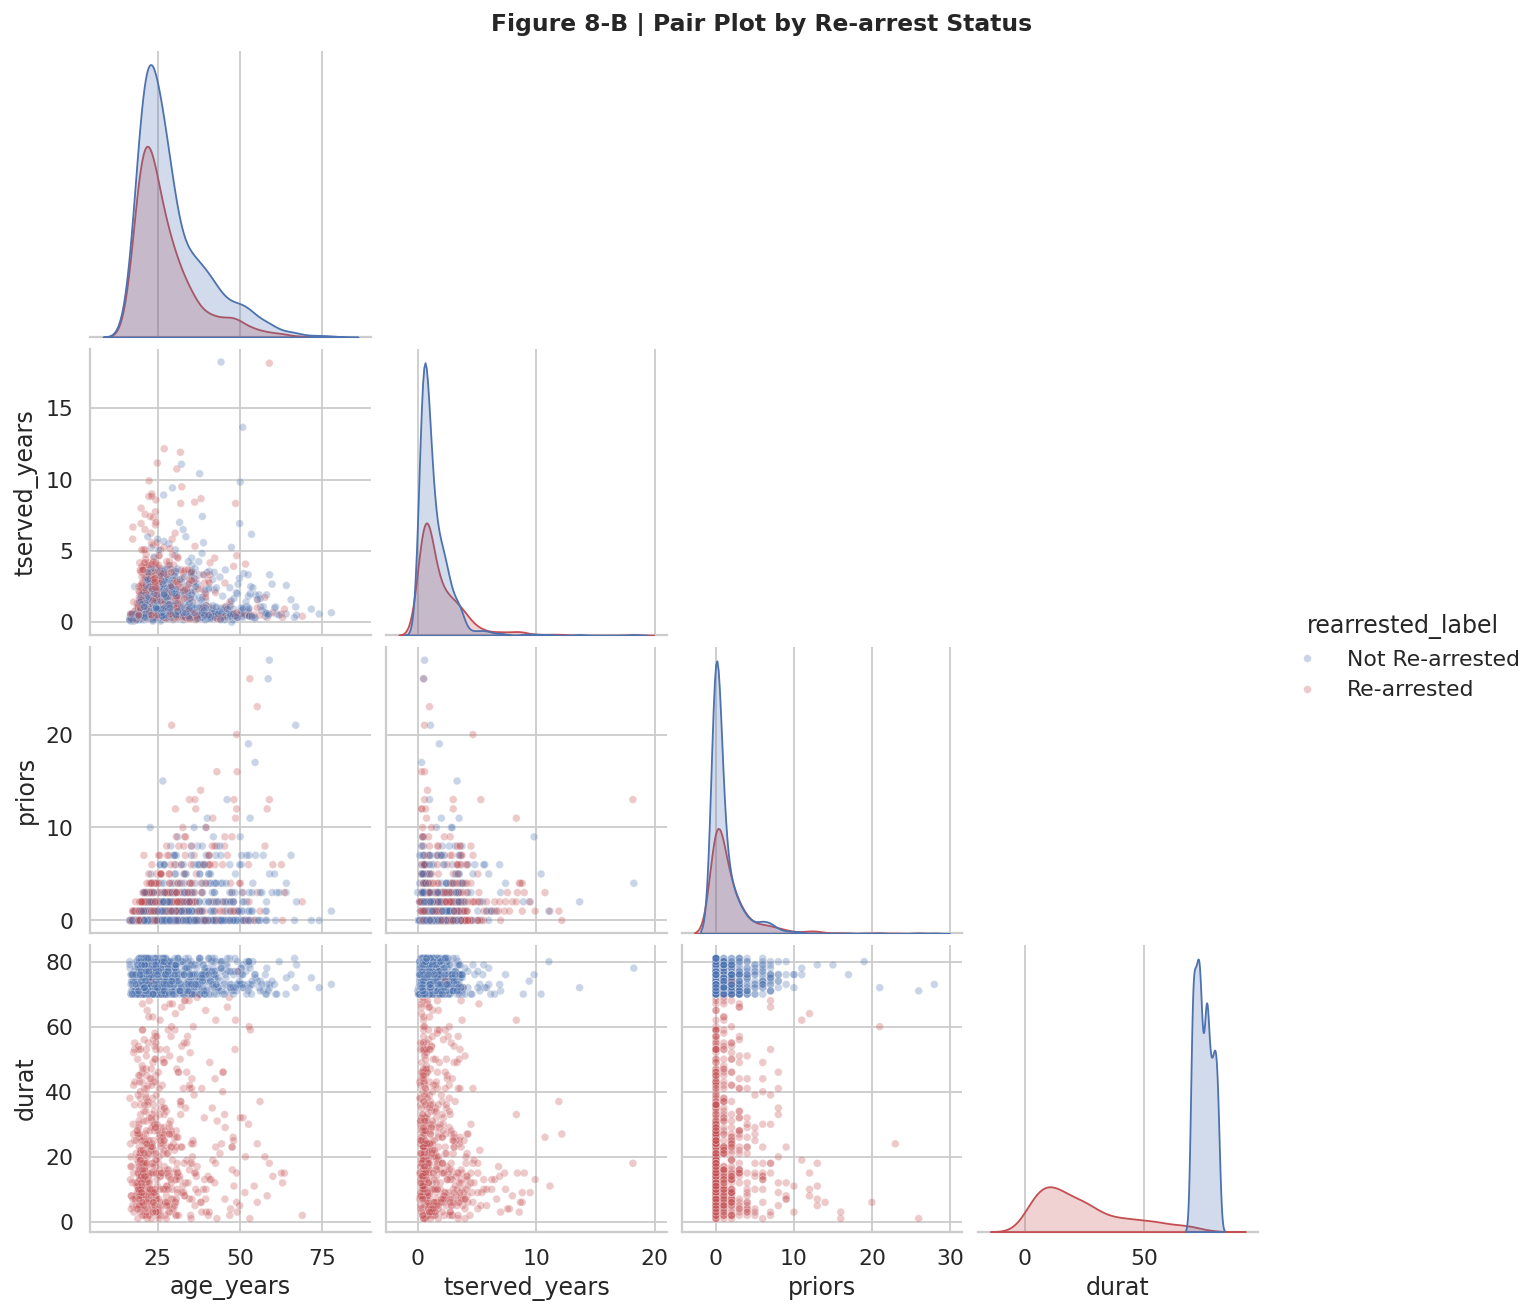

In [16]:
pair_cols = ["age_years", "tserved_years", "priors", "durat"]
pair_df = df[pair_cols + ["rearrested_label"]].copy()

g = sns.pairplot(
    pair_df,
    hue="rearrested_label",
    palette={
        "Not Re-arrested": "#4C72B0",
        "Re-arrested": "#C44E52"
    },
    plot_kws={
        "alpha": 0.3,
        "s": 18
    },
    diag_kind="kde",
    corner=True
)

g.figure.suptitle(
    "Figure 8-B | Pair Plot by Re-arrest Status",
    y=1.01,
    fontsize=13,
    fontweight="bold"
)

plt.show()

**Multivariate · Faceted KDE**

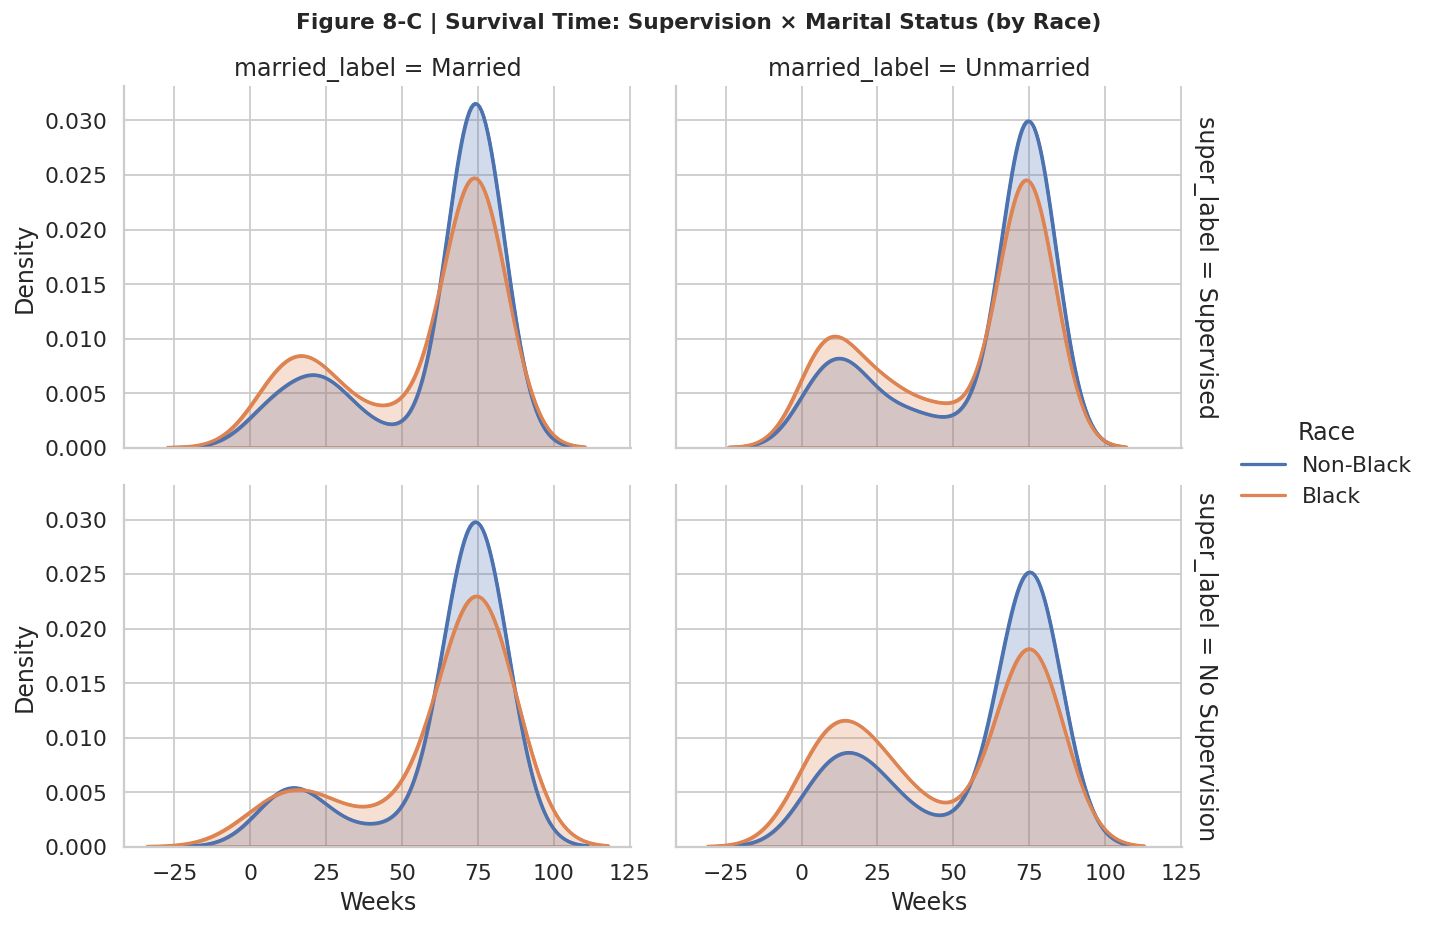

In [17]:
df["super_label"] = df["super"].map({
    0: "No Supervision",
    1: "Supervised"
})

df["married_label"] = df["married"].map({
    0: "Unmarried",
    1: "Married"
})

df["race_label"] = df["black"].map({
    0: "Non-Black",
    1: "Black"
})

g = sns.FacetGrid(
    df,
    row="super_label",
    col="married_label",
    hue="race_label",
    palette={
        "Non-Black": "#4C72B0",
        "Black": "#DD8452"
    },
    height=3.5,
    aspect=1.4,
    margin_titles=True
)

g.map(sns.kdeplot, "durat", fill=True, alpha=0.25, linewidth=1.8)
g.map(sns.kdeplot, "durat", linewidth=1.8)

g.add_legend(title="Race")
g.set_axis_labels("Weeks", "Density")

g.figure.suptitle(
    "Figure 8-C | Survival Time: Supervision × Marital Status (by Race)",
    y=1.02,
    fontsize=12,
    fontweight="bold"
)

plt.show()

**Multivariate · Priors Band × Alcohol → Re-arrest Rate**

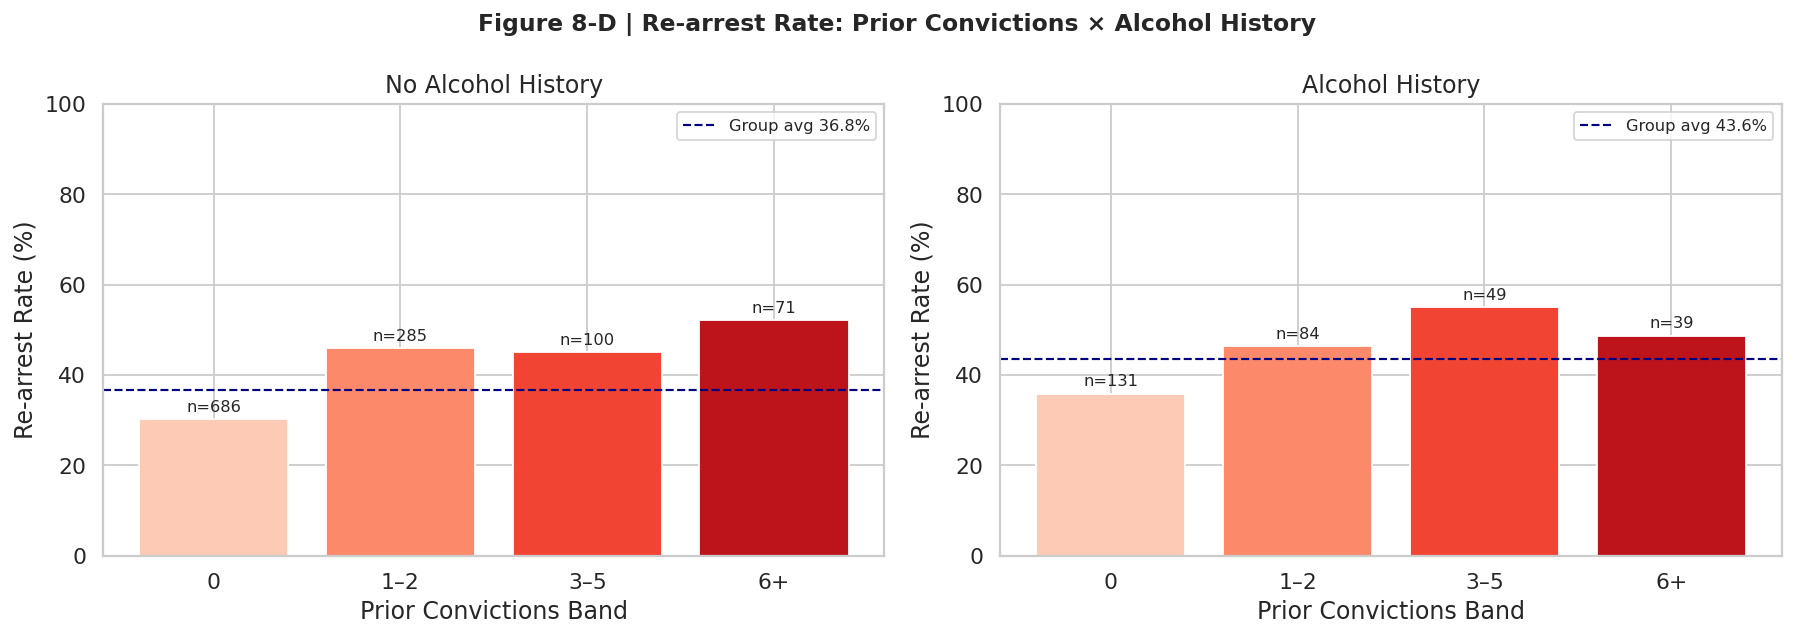

In [18]:
rate_df = (
    df.groupby(["priors_bin", "alcohol"], observed=True)["rearrested"]
    .agg(
        rate=lambda x: x.mean() * 100,
        n="count"
    )
    .reset_index()
)

rate_df["alcohol_label"] = rate_df["alcohol"].map({
    0: "No Alcohol History",
    1: "Alcohol History"
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Figure 8-D | Re-arrest Rate: Prior Convictions × Alcohol History",
    fontsize=13,
    fontweight="bold"
)

titles = ["No Alcohol History", "Alcohol History"]

for ax, alcohol, title in zip(axes, [0, 1], titles):
    subset = rate_df[rate_df["alcohol"] == alcohol]

    bars = ax.bar(
        subset["priors_bin"].astype(str),
        subset["rate"],
        color=sns.color_palette("Reds", len(subset)),
        edgecolor="white"
    )

    for bar, row in zip(bars, subset.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"n={row.n}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    avg_rate = df[df["alcohol"] == alcohol]["rearrested"].mean() * 100

    ax.axhline(
        avg_rate,
        color="navy",
        linestyle="--",
        linewidth=1.2,
        label=f"Group avg {avg_rate:.1f}%"
    )

    ax.set(
        title=title,
        xlabel="Prior Convictions Band",
        ylabel="Re-arrest Rate (%)",
        ylim=(0, 100)
    )

    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Multivariate · 3D Scatter**

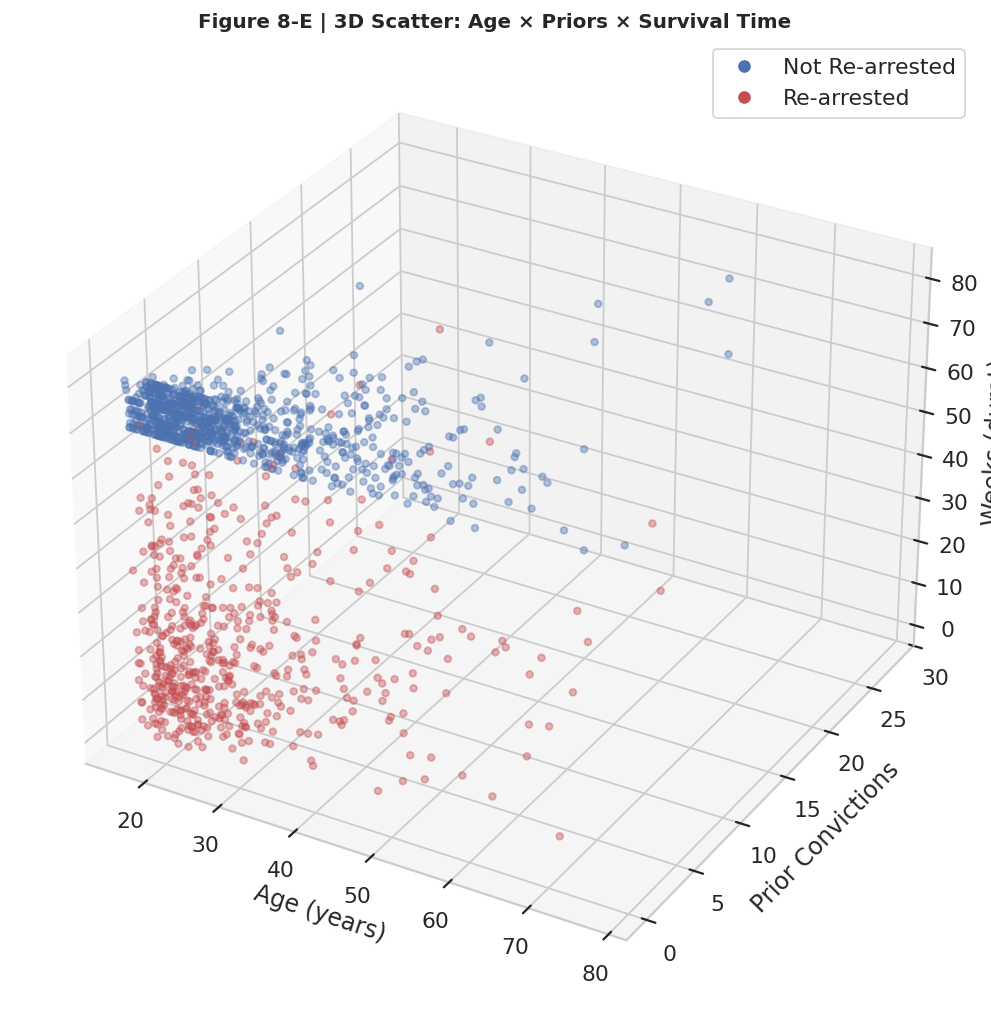

In [19]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

colors = df["rearrested"].map({
    0: "#4C72B0",
    1: "#C44E52"
})

ax.scatter(
    df["age_years"],
    df["priors"],
    df["durat"],
    c=colors,
    alpha=0.4,
    s=14
)

legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#4C72B0",
        markersize=8,
        label="Not Re-arrested"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#C44E52",
        markersize=8,
        label="Re-arrested"
    )
]

ax.legend(handles=legend_items, loc="upper right")

ax.set(
    xlabel="Age (years)",
    ylabel="Prior Convictions",
    zlabel="Weeks (durat)"
)

ax.set_title(
    "Figure 8-E | 3D Scatter: Age × Priors × Survival Time",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()